# Stage 3 Instruction Model Evaluation

Evaluate the current instruction checkpoint with safe prompts, generation-format checks, token-budget checks, checkpoint training metrics, and quick soluble-protein filters.

This notebook is a first-pass model evaluation. It does not prove biological function or safety. Generated sequences still need external validation such as BLASTP, InterProScan, SignalP, DeepTMHMM, toxicity, and allergenicity checks.

## Bootstrap

In [1]:
import gc
import json
import math
import os
import random
import sys
import time
from collections import Counter
from pathlib import Path
from typing import Any, Mapping

import torch


def find_repo_dir_for_import(start: Path) -> Path:
    candidates = [start.resolve(), *start.resolve().parents]
    repo_dir_env = os.environ.get("MDNAC_REPO_DIR")
    if repo_dir_env:
        candidates.append(Path(repo_dir_env).expanduser())
    candidates.extend([
        Path("/content/MDNAC"),
        Path("/content/drive/MyDrive/MDNAC"),
    ])
    for candidate in candidates:
        resolved = candidate.expanduser().resolve()
        if (resolved / "pyproject.toml").exists() and (resolved / "libs").is_dir():
            return resolved
    raise RuntimeError("Could not locate repo. Run from the repo or set MDNAC_REPO_DIR.")


REPO_DIR = find_repo_dir_for_import(Path.cwd())
if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

from libs.core.app import MicrobialDecoderCoreApp
from libs.core.fusion import FusedVocabularyLayout
from libs.core.mdc.config import MDCModelConfig
from libs.core.pretrain.profiled import MDCProfileSequencePretrainArtifacts
from libs.instruction.schema import format_instruction_prompt
from libs.instruction.trainer import INSTRUCTION_CHECKPOINT_FAMILY
import libs.core.mdc.linear_attention as linear_attention

print(f"Repo: {REPO_DIR}")
print(f"Torch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Repo: C:\Users\Admin\Desktop\MDNAC
Torch: 2.11.0+cu128
CUDA: True
GPU: NVIDIA GeForce RTX 5060 Ti


## Settings

In [3]:
INSTRUCTION_CHECKPOINT_CANDIDATES = [
    REPO_DIR / "data/checkpoints/protein_instruction/checkpoint_best.pt",
    REPO_DIR / "data/checkpoints/protein_instruction/checkpoint_last.pt",
    REPO_DIR / "data/checkpoints/protein_instruction/checkpoint_final.pt",
]
ARTIFACT_DIR = REPO_DIR / "data/compiled/refseq_bacteria_instruction_profile"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MIXED_PRECISION = "auto"  # "auto", "bf16", "fp16", or "no"
USE_FP32_LINEAR_ATTENTION_FALLBACK = False

# Increase these after the first successful evaluation run.
EVAL_NUM_CANDIDATES_PER_PROMPT = 4
EVAL_MAX_NEW_TOKENS = 160
EVAL_MIN_GENERATION_TOKENS = 80
EVAL_TEMPERATURE = 0.8
EVAL_TOP_K = 50
EVAL_SEED = 123
EVAL_VERBOSE_GENERATION = False

linear_attention.use_fp32_fallback_linear_attention = USE_FP32_LINEAR_ATTENTION_FALLBACK


## Load Current Instruction Checkpoint

In [4]:
def first_existing(paths):
    for path in paths:
        path = Path(path)
        if path.is_file():
            return path
    return None


def coerce_torch_dtype(value: Any) -> torch.dtype:
    if isinstance(value, torch.dtype):
        return value
    text = str(value).replace("torch.", "")
    mapping = {
        "float32": torch.float32,
        "float": torch.float32,
        "float16": torch.float16,
        "half": torch.float16,
        "bfloat16": torch.bfloat16,
    }
    return mapping.get(text, torch.float32)


def model_config_from_checkpoint(checkpoint: Mapping[str, Any]) -> MDCModelConfig:
    payload = dict(checkpoint.get("model_config") or {})
    if not payload:
        raise ValueError("Checkpoint is missing model_config.")
    if payload.get("layer_types") is not None:
        payload["layer_types"] = tuple(payload["layer_types"])
    payload["dtype"] = coerce_torch_dtype(payload.get("dtype", torch.float32))
    return MDCModelConfig(**payload)


def normalize_app_state_dict(state_dict: Mapping[str, Any]) -> dict[str, Any]:
    normalized = dict(state_dict)
    for prefix in ("module.", "_orig_mod."):
        while normalized and all(key.startswith(prefix) for key in normalized):
            normalized = {key[len(prefix):]: value for key, value in normalized.items()}
    return normalized


def autocast_dtype() -> torch.dtype | None:
    if DEVICE.type != "cuda" or MIXED_PRECISION == "no":
        return None
    if MIXED_PRECISION == "bf16":
        return torch.bfloat16
    if MIXED_PRECISION == "fp16":
        return torch.float16
    if MIXED_PRECISION != "auto":
        raise ValueError("MIXED_PRECISION must be 'auto', 'bf16', 'fp16', or 'no'.")
    return torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16


def load_instruction_runtime(checkpoint_path: Path, artifact_dir: Path | None = None):
    checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
    if checkpoint.get("model_family") != INSTRUCTION_CHECKPOINT_FAMILY:
        raise ValueError(f"Not an instruction checkpoint: {checkpoint.get('model_family')!r}")

    cfg = model_config_from_checkpoint(checkpoint)
    layout = FusedVocabularyLayout.from_raw_tensor_payload({"config": checkpoint["layout"]})
    app = MicrobialDecoderCoreApp(cfg, layout)
    app.load_state_dict(normalize_app_state_dict(checkpoint["model_state_dict"]), strict=True)
    app.to(DEVICE).eval()

    artifact_dir_candidates = []
    if artifact_dir is not None:
        artifact_dir_candidates.append(Path(artifact_dir))
    artifact_dir_candidates.append(ARTIFACT_DIR)
    checkpoint_artifact_dir = checkpoint.get("artifact_dir")
    if checkpoint_artifact_dir:
        artifact_dir_candidates.append(Path(checkpoint_artifact_dir))

    tried_tokenizer_maps = []
    tokenizer_map_path = None
    for candidate_dir in artifact_dir_candidates:
        candidate_path = candidate_dir / "tokenizer_map.json"
        tried_tokenizer_maps.append(candidate_path)
        if candidate_path.is_file():
            tokenizer_map_path = candidate_path
            break
    if tokenizer_map_path is None:
        tried = "\n  - ".join(str(path) for path in tried_tokenizer_maps)
        raise FileNotFoundError(
            "Missing instruction artifact tokenizer map. Tried:\n"
            f"  - {tried}\n"
            "Run the instruction training notebook first, or set ARTIFACT_DIR."
        )
    artifacts = MDCProfileSequencePretrainArtifacts.from_tokenizer_map_file(tokenizer_map_path)
    return {
        "kind": "instruction",
        "checkpoint_path": checkpoint_path,
        "checkpoint": checkpoint,
        "model": app,
        "artifacts": artifacts,
        "layout": layout,
        "context_length": int(cfg.context_length),
        "tokenizer_map_path": tokenizer_map_path,
    }


checkpoint_path = first_existing(INSTRUCTION_CHECKPOINT_CANDIDATES)
if checkpoint_path is None:
    raise FileNotFoundError("No instruction checkpoint found in INSTRUCTION_CHECKPOINT_CANDIDATES.")

print(f"Loading instruction checkpoint: {checkpoint_path}")
RUNTIME = load_instruction_runtime(checkpoint_path)
print(json.dumps({
    "kind": RUNTIME["kind"],
    "checkpoint_path": str(RUNTIME["checkpoint_path"]),
    "tokenizer_map_path": str(RUNTIME["tokenizer_map_path"]),
    "context_length": RUNTIME["context_length"],
    "device": str(DEVICE),
    "autocast_dtype": str(autocast_dtype()),
}, indent=2))

Loading instruction checkpoint: C:\Users\Admin\Desktop\MDNAC\data\checkpoints\protein_instruction\checkpoint_best.pt
The MDC fast path is unavailable (missing optional libraries: causal-conv1d, flash-linear-attention). Falling back to the torch implementation. Fallback is using ambient dtype (fp16/bf16) — verify loss is finite.
{
  "kind": "instruction",
  "checkpoint_path": "C:\\Users\\Admin\\Desktop\\MDNAC\\data\\checkpoints\\protein_instruction\\checkpoint_best.pt",
  "tokenizer_map_path": "C:\\Users\\Admin\\Desktop\\MDNAC\\data\\compiled\\refseq_bacteria_instruction_profile\\tokenizer_map.json",
  "context_length": 512,
  "device": "cuda",
  "autocast_dtype": "torch.bfloat16"
}


## Checkpoint Metrics

In [5]:
def finite_float(value) -> float | None:
    try:
        number = float(value)
    except (TypeError, ValueError):
        return None
    return number if math.isfinite(number) else None


def loss_to_perplexity(loss) -> float | None:
    loss = finite_float(loss)
    if loss is None or loss > 50:
        return None
    return float(math.exp(loss))


def read_jsonl(path: Path) -> list[dict[str, Any]]:
    if not path.is_file():
        return []
    rows = []
    with path.open("r", encoding="utf-8") as handle:
        for raw_line in handle:
            if raw_line.strip():
                rows.append(json.loads(raw_line))
    return rows


checkpoint = RUNTIME["checkpoint"]
metrics_path = Path(RUNTIME["checkpoint_path"]).parent / "metrics_history.jsonl"
metrics_history = read_jsonl(metrics_path)
train_losses = list(checkpoint.get("train_losses") or [])
val_losses = list(checkpoint.get("val_losses") or [])

checkpoint_metrics = {
    "checkpoint_path": str(RUNTIME["checkpoint_path"]),
    "epoch": checkpoint.get("epoch"),
    "global_step": checkpoint.get("global_step"),
    "tokens_seen": checkpoint.get("tokens_seen"),
    "best_val_loss": checkpoint.get("best_val_loss"),
    "best_val_perplexity": loss_to_perplexity(checkpoint.get("best_val_loss")),
    "latest_train_loss": train_losses[-1] if train_losses else None,
    "latest_val_loss": val_losses[-1] if val_losses else None,
    "latest_val_perplexity": loss_to_perplexity(val_losses[-1]) if val_losses else None,
    "eval_points_in_checkpoint": len(val_losses),
    "metrics_history_path": str(metrics_path),
    "metrics_history_rows": len(metrics_history),
}
print(json.dumps(checkpoint_metrics, indent=2))

if metrics_history:
    print("\nLast metrics rows:")
    for row in metrics_history[-5:]:
        print(json.dumps(row, ensure_ascii=False))

{
  "checkpoint_path": "C:\\Users\\Admin\\Desktop\\MDNAC\\data\\checkpoints\\protein_instruction\\checkpoint_best.pt",
  "epoch": 1,
  "global_step": 5250,
  "tokens_seen": 49770879,
  "best_val_loss": 3.918243709951639,
  "best_val_perplexity": 50.31200466444772,
  "latest_train_loss": 3.747140519320965,
  "latest_val_loss": 3.918243709951639,
  "latest_val_perplexity": 50.31200466444772,
  "eval_points_in_checkpoint": 105,
  "metrics_history_path": "C:\\Users\\Admin\\Desktop\\MDNAC\\data\\checkpoints\\protein_instruction\\metrics_history.jsonl",
  "metrics_history_rows": 107
}

Last metrics rows:
{"epoch": 1, "global_step": 5150, "tokens_seen": 48873855, "train_loss": 3.7297511659562588, "val_loss": 3.925734542310238, "best_val_loss": 3.925734542310238}
{"epoch": 1, "global_step": 5200, "tokens_seen": 49325246, "train_loss": 3.745982352644205, "val_loss": 3.9208031371235847, "best_val_loss": 3.9208031371235847}
{"epoch": 1, "global_step": 5250, "tokens_seen": 49770879, "train_loss": 

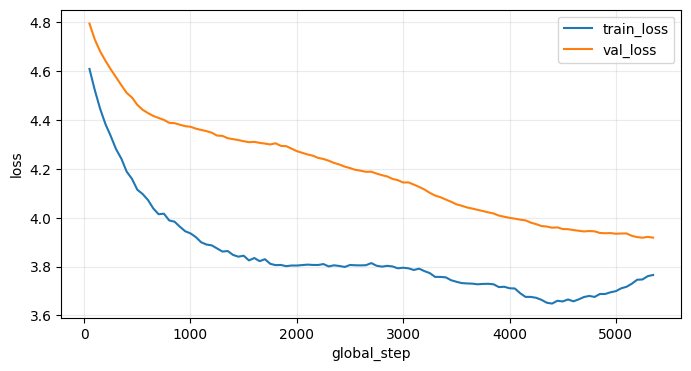

In [6]:
# Optional loss curve plot.
if metrics_history:
    import matplotlib.pyplot as plt

    steps = [row.get("global_step") for row in metrics_history]
    train = [row.get("train_loss") for row in metrics_history]
    val = [row.get("val_loss") for row in metrics_history]
    plt.figure(figsize=(8, 4))
    plt.plot(steps, train, label="train_loss")
    plt.plot(steps, val, label="val_loss")
    plt.xlabel("global_step")
    plt.ylabel("loss")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()
else:
    print("No metrics_history.jsonl found; skipping plot.")

## Safe Evaluation Prompt Suite

In [7]:
EVALUATION_PROMPTS = [
    {
        "name": "safe_soluble_cytosolic",
        "instruction": (
            "Generate one soluble non-pathogenic E. coli-like cytosolic protein using ACDEFGHIKLMNPQRSTVWY only. "
            "Length 100-220 aa. Favor charged/polar residues. "
            "Avoid signal peptide, transmembrane, secretion, adhesion, toxin, virulence, resistance, "
            "host-colonization, aerosol-survival, and low-complexity motifs. Output sequence only."
        ),
        "input_text": (
            "Computational screening only. Reject pathogenicity, transmission, secretion, membrane anchoring, "
            "toxicity, antimicrobial resistance, and airborne/aerosol fitness."
        ),
    },
    {
        "name": "safe_enzyme_like",
        "instruction": (
            "Generate one soluble bacterial enzyme-like cytosolic protein using ACDEFGHIKLMNPQRSTVWY only. "
            "Length 100-220 aa. Favor charged/polar residues and avoid long hydrophobic runs. "
            "Do not include signal peptide, transmembrane, toxin, virulence, resistance, secretion, or adhesion motifs. "
            "Output sequence only."
        ),
        "input_text": "Computational candidate for downstream non-pathogenic screening.",
    },
    {
        "name": "safe_structural_like",
        "instruction": (
            "Generate one soluble intracellular bacterial structural-like protein sequence using ACDEFGHIKLMNPQRSTVWY only. "
            "Length 100-220 aa. Prefer polar/charged residues. "
            "Avoid membrane localization, secretion, toxin, virulence, resistance, host interaction, and low-complexity motifs. "
            "Output sequence only."
        ),
        "input_text": "Use only for computational model evaluation and external safety screening.",
    },
]

print(json.dumps([{"name": item["name"]} for item in EVALUATION_PROMPTS], indent=2))

[
  {
    "name": "safe_soluble_cytosolic"
  },
  {
    "name": "safe_enzyme_like"
  },
  {
    "name": "safe_structural_like"
  }
]


## Generation Helpers

In [8]:
def sample_next_token(logits: torch.Tensor, *, temperature: float, top_k: int | None) -> torch.Tensor:
    if top_k is not None and top_k > 0:
        top_k = min(int(top_k), logits.size(-1))
        top_values, _ = torch.topk(logits, k=top_k, dim=-1)
        threshold = top_values[:, -1].unsqueeze(-1)
        logits = torch.where(logits < threshold, torch.full_like(logits, float("-inf")), logits)

    if temperature and temperature > 0:
        probs = torch.softmax(logits / float(temperature), dim=-1)
        return torch.multinomial(probs, num_samples=1)
    return torch.argmax(logits, dim=-1, keepdim=True)


def set_seed(seed: int | None) -> None:
    if seed is None:
        return
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def fused_instruction_prompt(artifacts, instruction: str, input_text: str = "") -> torch.Tensor:
    layout = artifacts.layout
    profile = format_instruction_prompt(instruction, input_text)
    profile_ids = artifacts.profile_tokenizer.encode(profile, add_bos=True, add_eos=True)

    if profile_ids and profile_ids[0] == 1:
        profile_ids = profile_ids[1:]
    if profile_ids and profile_ids[-1] == 2:
        profile_ids = profile_ids[:-1]

    fused_ids = [layout.bos_token_id]
    fused_ids.extend(layout.map_profile_token_id(token_id) for token_id in profile_ids)
    fused_ids.append(layout.sep_token_id)
    return torch.tensor(fused_ids, dtype=torch.long, device=DEVICE).unsqueeze(0)


def instruction_prompt_token_count(instruction: str, input_text: str = "") -> int:
    return int(fused_instruction_prompt(RUNTIME["artifacts"], instruction, input_text).size(1))


def prompt_budget_report(instruction: str, input_text: str = "") -> dict[str, int]:
    prompt_tokens = instruction_prompt_token_count(instruction, input_text)
    context_tokens = int(RUNTIME["context_length"])
    return {
        "prompt_tokens": prompt_tokens,
        "context_tokens": context_tokens,
        "available_generation_tokens": context_tokens - prompt_tokens,
    }


def safe_max_new_tokens(instruction: str, input_text: str = "") -> int:
    budget = prompt_budget_report(instruction, input_text)
    available = int(budget["available_generation_tokens"])
    if available < int(EVAL_MIN_GENERATION_TOKENS):
        raise ValueError(
            f"Prompt leaves only {available} generation tokens. "
            f"Shorten prompt until at least {EVAL_MIN_GENERATION_TOKENS} are available."
        )
    return min(int(EVAL_MAX_NEW_TOKENS), available)


def mask_to_sequence_vocab(logits: torch.Tensor, layout) -> torch.Tensor:
    masked = torch.full_like(logits, float("-inf"))
    start = int(layout.sequence_offset)
    end = start + int(layout.sequence_vocab_size)
    masked[:, start:end] = logits[:, start:end]
    masked[:, int(layout.eos_token_id)] = logits[:, int(layout.eos_token_id)]
    return masked


def decode_generated_sequence(artifacts, generated_fused_ids: list[int]) -> str:
    layout = artifacts.layout
    sequence_ids = []
    for token_id in generated_fused_ids:
        token_id = int(token_id)
        if token_id == layout.eos_token_id:
            break
        if layout.sequence_offset <= token_id < layout.sequence_offset + layout.sequence_vocab_size:
            sequence_ids.append(token_id - layout.sequence_offset)
    return artifacts.decode_sequence(sequence_ids, skip_special=True)


def generate_instruction_response(
    instruction: str,
    input_text: str = "",
    *,
    max_new_tokens: int,
    temperature: float = EVAL_TEMPERATURE,
    top_k: int | None = EVAL_TOP_K,
    seed: int | None = None,
    verbose: bool = EVAL_VERBOSE_GENERATION,
    progress_every: int = 16,
) -> dict[str, Any]:
    set_seed(seed)
    app = RUNTIME["model"]
    artifacts = RUNTIME["artifacts"]
    layout = artifacts.layout
    prompt_ids = fused_instruction_prompt(artifacts, instruction, input_text)
    prompt_length = int(prompt_ids.size(1))
    max_context = int(RUNTIME["context_length"])
    generated_ids: list[int] = []
    amp_dtype = autocast_dtype()

    if prompt_length >= max_context:
        raise ValueError(f"Prompt length {prompt_length} is already >= context length {max_context}.")

    start_time = time.time()
    with torch.no_grad():
        cache = app.model.create_kv_cache()
        app.model.reset_kv_cache(cache)
        with torch.amp.autocast(DEVICE.type, dtype=amp_dtype, enabled=(amp_dtype is not None)):
            logits = app.model(prompt_ids, cache=cache)[:, -1, :]

        for step in range(int(max_new_tokens)):
            if prompt_length + len(generated_ids) >= max_context:
                break
            next_logits = mask_to_sequence_vocab(logits, layout)
            next_token = sample_next_token(next_logits, temperature=temperature, top_k=top_k)
            next_id = int(next_token.item())
            generated_ids.append(next_id)
            if verbose and progress_every > 0 and (step + 1) % int(progress_every) == 0:
                print(f"generated {step + 1}/{max_new_tokens} tokens", flush=True)
            if next_id == layout.eos_token_id:
                break
            with torch.amp.autocast(DEVICE.type, dtype=amp_dtype, enabled=(amp_dtype is not None)):
                logits = app.model(next_token, cache=cache)[:, -1, :]

    sequence = decode_generated_sequence(artifacts, generated_ids)
    return {
        "sequence": sequence,
        "sequence_length": len(sequence),
        "prompt_tokens": prompt_length,
        "generated_tokens": len(generated_ids),
        "stopped_on_eos": bool(generated_ids and generated_ids[-1] == layout.eos_token_id),
        "seconds": round(time.time() - start_time, 3),
    }

## Quick Output Filters

In [9]:
ALLOWED_AA = set("ACDEFGHIKLMNPQRSTVWY")
HYDROPHOBIC_AA = set("AILMFWVY")

MIN_SEQUENCE_LENGTH = 100
MAX_SEQUENCE_LENGTH = 220
MAX_LONGEST_HYDROPHOBIC_STRETCH = 10
MAX_TERMINAL_HYDROPHOBIC_FRACTION = 0.40
MAX_SINGLE_AA_RUN = 12
MAX_SINGLE_AA_FRACTION = 0.35


def longest_run(sequence: str, alphabet: set[str] | None = None) -> int:
    longest = current = 0
    previous = None
    for aa in sequence:
        matches = aa in alphabet if alphabet is not None else aa == previous
        if alphabet is None:
            current = current + 1 if aa == previous else 1
        elif matches:
            current += 1
        else:
            current = 0
        longest = max(longest, current)
        previous = aa
    return longest


def quick_sequence_report(sequence: str) -> dict[str, Any]:
    seq = "".join(str(sequence or "").split()).upper()
    length = len(seq)
    safe_length = max(length, 1)
    counts = Counter(seq)
    n_term = seq[:30]
    c_term = seq[-30:]
    hydrophobic_fraction = sum(aa in HYDROPHOBIC_AA for aa in seq) / safe_length
    n_term_hydrophobic_fraction = sum(aa in HYDROPHOBIC_AA for aa in n_term) / max(len(n_term), 1)
    c_term_hydrophobic_fraction = sum(aa in HYDROPHOBIC_AA for aa in c_term) / max(len(c_term), 1)
    longest_hydrophobic = longest_run(seq, HYDROPHOBIC_AA)
    longest_single_aa = longest_run(seq)
    max_single_aa_fraction = max(counts.values(), default=0) / safe_length

    reject_reasons = []
    if not seq:
        reject_reasons.append("empty_sequence")
    if any(aa not in ALLOWED_AA for aa in seq):
        reject_reasons.append("invalid_amino_acid_alphabet")
    if not (MIN_SEQUENCE_LENGTH <= length <= MAX_SEQUENCE_LENGTH):
        reject_reasons.append(f"length_{length}_outside_{MIN_SEQUENCE_LENGTH}_{MAX_SEQUENCE_LENGTH}")
    if longest_hydrophobic > MAX_LONGEST_HYDROPHOBIC_STRETCH:
        reject_reasons.append(f"longest_hydrophobic_{longest_hydrophobic}_gt_{MAX_LONGEST_HYDROPHOBIC_STRETCH}")
    if n_term_hydrophobic_fraction >= MAX_TERMINAL_HYDROPHOBIC_FRACTION:
        reject_reasons.append(f"n_terminal_hydrophobic_fraction_{n_term_hydrophobic_fraction:.3f}")
    if c_term_hydrophobic_fraction >= MAX_TERMINAL_HYDROPHOBIC_FRACTION:
        reject_reasons.append(f"c_terminal_hydrophobic_fraction_{c_term_hydrophobic_fraction:.3f}")
    if longest_single_aa > MAX_SINGLE_AA_RUN:
        reject_reasons.append(f"single_aa_run_{longest_single_aa}_gt_{MAX_SINGLE_AA_RUN}")
    if max_single_aa_fraction > MAX_SINGLE_AA_FRACTION:
        reject_reasons.append(f"single_aa_fraction_{max_single_aa_fraction:.3f}_gt_{MAX_SINGLE_AA_FRACTION}")

    return {
        "length": length,
        "valid_alphabet": all(aa in ALLOWED_AA for aa in seq) and bool(seq),
        "length_ok": MIN_SEQUENCE_LENGTH <= length <= MAX_SEQUENCE_LENGTH,
        "hydrophobic_fraction": round(hydrophobic_fraction, 3),
        "n_term_hydrophobic_fraction": round(n_term_hydrophobic_fraction, 3),
        "c_term_hydrophobic_fraction": round(c_term_hydrophobic_fraction, 3),
        "longest_hydrophobic_stretch": longest_hydrophobic,
        "longest_single_aa_run": longest_single_aa,
        "max_single_aa_fraction": round(max_single_aa_fraction, 3),
        "passes_quick_filter": not reject_reasons,
        "reject_reasons": reject_reasons,
    }

## Run Generation Evaluation

In [10]:
evaluation_rows = []

for prompt_index, prompt in enumerate(EVALUATION_PROMPTS):
    name = prompt["name"]
    instruction = prompt["instruction"]
    input_text = prompt.get("input_text", "")
    budget = prompt_budget_report(instruction, input_text)
    print(f"\nPrompt: {name}")
    print(json.dumps(budget, indent=2))

    max_new_tokens = safe_max_new_tokens(instruction, input_text)
    for candidate_index in range(int(EVAL_NUM_CANDIDATES_PER_PROMPT)):
        seed = int(EVAL_SEED) + prompt_index * 1000 + candidate_index
        print(f"Generating {name} candidate {candidate_index + 1}/{EVAL_NUM_CANDIDATES_PER_PROMPT}...")
        item = generate_instruction_response(
            instruction,
            input_text,
            max_new_tokens=max_new_tokens,
            temperature=EVAL_TEMPERATURE,
            top_k=EVAL_TOP_K,
            seed=seed,
            verbose=EVAL_VERBOSE_GENERATION,
        )
        report = quick_sequence_report(item["sequence"])
        row = {
            "prompt_name": name,
            "candidate_index": candidate_index + 1,
            "seed": seed,
            **budget,
            "max_new_tokens": max_new_tokens,
            "generated_tokens": item["generated_tokens"],
            "stopped_on_eos": item["stopped_on_eos"],
            "seconds": item["seconds"],
            **report,
            "sequence": item["sequence"],
        }
        evaluation_rows.append(row)
        status = "PASS" if report["passes_quick_filter"] else "REJECT"
        print(f"{status}: length={report['length']} tokens={item['generated_tokens']} reasons={report['reject_reasons']}")

print(f"\nGenerated {len(evaluation_rows)} evaluation candidates.")


Prompt: safe_soluble_cytosolic
{
  "prompt_tokens": 391,
  "context_tokens": 512,
  "available_generation_tokens": 121
}
Generating safe_soluble_cytosolic candidate 1/4...


KeyboardInterrupt: 

## Summarize Evaluation

In [ ]:
def rate(rows, key: str) -> float | None:
    if not rows:
        return None
    return round(sum(bool(row.get(key)) for row in rows) / len(rows), 3)


def summarize_rows(rows: list[dict[str, Any]]) -> dict[str, Any]:
    if not rows:
        return {"candidate_count": 0}
    lengths = [int(row["length"]) for row in rows]
    generated_tokens = [int(row["generated_tokens"]) for row in rows]
    sequences = [row["sequence"] for row in rows]
    return {
        "candidate_count": len(rows),
        "valid_alphabet_rate": rate(rows, "valid_alphabet"),
        "length_ok_rate": rate(rows, "length_ok"),
        "quick_filter_pass_rate": rate(rows, "passes_quick_filter"),
        "eos_stop_rate": rate(rows, "stopped_on_eos"),
        "duplicate_sequence_count": len(sequences) - len(set(sequences)),
        "min_length": min(lengths),
        "mean_length": round(sum(lengths) / len(lengths), 2),
        "max_length": max(lengths),
        "mean_generated_tokens": round(sum(generated_tokens) / len(generated_tokens), 2),
        "mean_seconds": round(sum(float(row["seconds"]) for row in rows) / len(rows), 3),
    }


overall_summary = summarize_rows(evaluation_rows)
by_prompt_summary = {
    name: summarize_rows([row for row in evaluation_rows if row["prompt_name"] == name])
    for name in sorted({row["prompt_name"] for row in evaluation_rows})
}

print("Overall summary:")
print(json.dumps(overall_summary, indent=2))
print("\nBy prompt:")
print(json.dumps(by_prompt_summary, indent=2))

In [ ]:
def print_table(rows: list[dict[str, Any]], columns: list[str], limit: int | None = None) -> None:
    shown = rows[:limit] if limit is not None else rows
    if not shown:
        print("No rows.")
        return
    widths = {column: len(column) for column in columns}
    for row in shown:
        for column in columns:
            widths[column] = max(widths[column], len(str(row.get(column, ""))))
    header = " | ".join(column.ljust(widths[column]) for column in columns)
    print(header)
    print("-+-".join("-" * widths[column] for column in columns))
    for row in shown:
        print(" | ".join(str(row.get(column, "")).ljust(widths[column]) for column in columns))


table_columns = [
    "prompt_name",
    "candidate_index",
    "length",
    "generated_tokens",
    "valid_alphabet",
    "length_ok",
    "passes_quick_filter",
    "longest_hydrophobic_stretch",
    "longest_single_aa_run",
    "reject_reasons",
]
print_table(evaluation_rows, table_columns)

## Save Evaluation Report

In [ ]:
report_dir = REPO_DIR / "data/evaluations/instruction_model"
report_dir.mkdir(parents=True, exist_ok=True)
timestamp = time.strftime("%Y%m%d_%H%M%S")
report_path = report_dir / f"instruction_model_evaluation_{timestamp}.json"

report_payload = {
    "checkpoint_metrics": checkpoint_metrics,
    "settings": {
        "num_candidates_per_prompt": EVAL_NUM_CANDIDATES_PER_PROMPT,
        "max_new_tokens": EVAL_MAX_NEW_TOKENS,
        "min_generation_tokens": EVAL_MIN_GENERATION_TOKENS,
        "temperature": EVAL_TEMPERATURE,
        "top_k": EVAL_TOP_K,
        "seed": EVAL_SEED,
    },
    "overall_summary": overall_summary,
    "by_prompt_summary": by_prompt_summary,
    "rows": evaluation_rows,
    "external_validation_required": [
        "BLASTP",
        "InterProScan",
        "SignalP",
        "DeepTMHMM",
        "toxicity_prediction",
        "allergenicity_prediction",
    ],
}

report_path.write_text(json.dumps(report_payload, indent=2), encoding="utf-8")
print(f"Saved evaluation report: {report_path}")

## Interpretation Guide

A good first-pass result should have high `valid_alphabet_rate`, high `length_ok_rate`, high `quick_filter_pass_rate`, low duplicate count, and stable prompt token budgets. Treat these as model-quality indicators only. Any generated sequence intended for real biological interpretation must pass external validation and human review.